# Exercise - Simple Linear Regression



In this notebook you can check your understanding of linear regression and implement a linear regression model with scikit-learn by yourself. 




## Learning Objectives

At the end of this notebook, you should be able to: 
- Describe the relationship between two variables.
- Train a linear regression model with scikit-learn.
- Interpret the $R^2$ of a linear regression model.

## Question 1 



The scatter plots below show the relationship between height, diameter, and volume of timber in 31 felled black cherry trees. The diameter of the tree is measured 4.5 feet above the ground.  

<img src="assets/lin_reg_ex_1.png" width="600">  

**(a) Describe the relationship between volume and height of these trees.**

In [ ]:
# some relation but much scattered

**(b) Describe the relationship between volume and diameter of these trees.**

In [ ]:
# sronger linear

**(c) Suppose you measured the height and diameter of another black cherry tree. Which of these variables would be better for predicting the wood volume of this tree using a simple linear regression model? Explain your reasoning.**

In [ ]:
# volume and diameter

## Question 2 

The file `utils.csv` in your data folder contains information about the average utility bills for homes of a particular size and the average monthly temperature.  

**(a) Load the data:**

In [ ]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



In [21]:
# import the data from a csv-file
utils_loaded = pd.read_csv("data/utils.csv")

In [24]:
# it is case sensitive
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
utils_loaded["Month"] = pd.Categorical(utils_loaded["Month"],
                                       categories=month_order,
                                       ordered=True)
utils_loaded = utils_loaded.sort_values("Month")


utils_loaded.groupby("Month").describe()


Average Bill                                                \
             count   mean std    min    25%    50%    75%    max   
Month                                                              
Jan            1.0  148.5 NaN  148.5  148.5  148.5  148.5  148.5   
Feb            1.0  136.5 NaN  136.5  136.5  136.5  136.5  136.5   
Mar            1.0  117.0 NaN  117.0  117.0  117.0  117.0  117.0   
Apr            1.0   91.5 NaN   91.5   91.5   91.5   91.5   91.5   
May            1.0   82.5 NaN   82.5   82.5   82.5   82.5   82.5   
Jun            1.0   94.5 NaN   94.5   94.5   94.5   94.5   94.5   
Jul            1.0  120.0 NaN  120.0  120.0  120.0  120.0  120.0   
Aug            1.0  142.5 NaN  142.5  142.5  142.5  142.5  142.5   
Sep            1.0   97.5 NaN   97.5   97.5   97.5   97.5   97.5   
Oct            1.0   84.0 NaN   84.0   84.0   84.0   84.0   84.0   
Nov            1.0  111.0 NaN  111.0  111.0  111.0  111.0  111.0   
Dec            1.0  139.5 NaN  139.5  139.5  139.5  139.5  139.5   

      Average Monthly Temperature                                          
                            count  mean std   min   25%   50%   75%   max  
Month                                                                      
Jan                           1.0  38.0 NaN  38.0  38.0  38.0  38.0  38.0  
Feb                           1.0  45.0 NaN  45.0  45.0  45.0  45.0  45.0  
Mar                           1.0  49.0 NaN  49.0  49.0  49.0  49.0  49.0  
Apr                           1.0  57.0 NaN  57.0  57.0  57.0  57.0  57.0  
May                           1.0  69.0 NaN  69.0  69.0  69.0  69.0  69.0  
Jun                           1.0  78.0 NaN  78.0  78.0  78.0  78.0  78.0  
Jul                           1.0  84.0 NaN  84.0  84.0  84.0  84.0  84.0  
Aug                           1.0  89.0 NaN  89.0  89.0  89.0  89.0  89.0  
Sep                           1.0  79.0 NaN  79.0  79.0  79.0  79.0  79.0  
Oct                           1.0  64.0 NaN  64.0  64.0  64.0  64.0  64.0  
Nov                           1.0  54.0 NaN  54.0  54.0  54.0  54.0  54.0  
Dec                           1.0  41.0 NaN  41.0  41.0  41.0  41.0  41.0

**(b) Make a scatter plot of the data average bill vs average monthly temperature. Which variable would make the most sense as the response variable?**

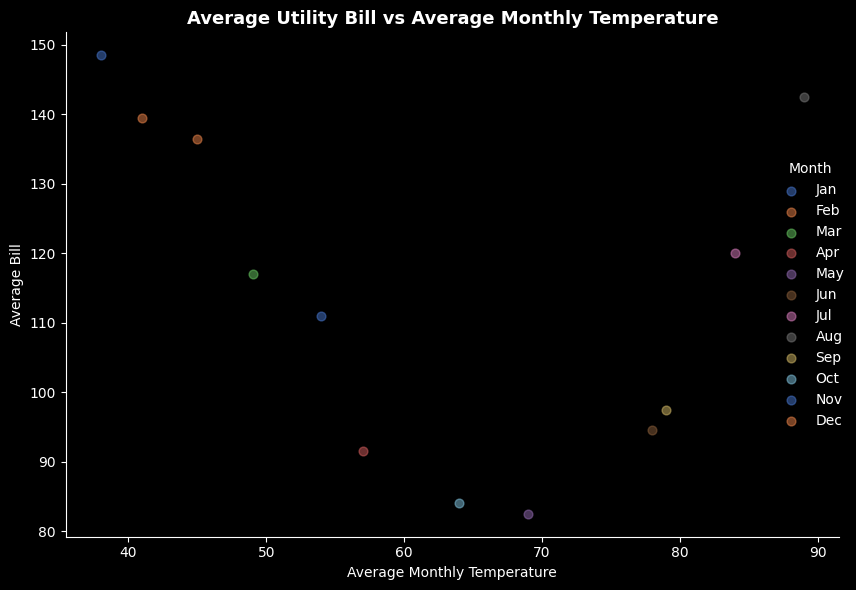

In [ ]:
# Y the response variable should be the bill because the temperature is something that cannot be controlled
sns.lmplot(
    data=utils_loaded,
    x="Average Monthly Temperature",
    y="Average Bill",
    hue="Month",
    hue_order=month_order,
    palette="muted",
    height=6,
    aspect=1.3,
    scatter_kws={"alpha": 0.5, "s": 40},
)

plt.title(
    "Average Utility Bill vs Average Monthly Temperature",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**(c) Have a look at the plot above. How would you describe the relationship between the variables?** 

In [ ]:
#parabola

**(d) Train a simple linear regression model using scikit-learn**

In [ ]:
# Prepare data for modeling by defining target and feature
X = utils_loaded[["Average Monthly Temperature"]]  # X needs to be 2-dimensional so we need double brackets here --> try to figure out why
y = utils_loaded["Average Bill"]

X.shape


lin_reg = LinearRegression() # this is the model name

# Train the model using our data
lin_reg.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.48]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Average Monthly Temperature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,143.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [ ]:
# Intercept and slope/coefficient can be accessed via .intercept_ and .coef_
intercept = lin_reg.intercept_
slope = lin_reg.coef_[0]
print("Model intercept:", intercept)
print("Coefficient for feature Temperature:", slope)

y_hat = lin_reg.predict(X) # this is the function

# Calculate the R-squared for our model
print("R-squared:", round(r2_score(y, y_hat), 3))

Model intercept: 143.62280506779285
Coefficient for feature Temperature: -0.4798844187597245
R-squared: 0.124


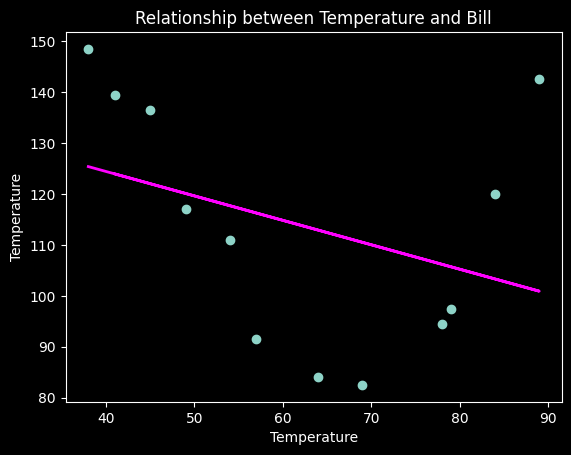

In [32]:
# Plotting our data points
plt.scatter(X, y)

# Adding the fitted regression line of our model
plt.plot(X, X * slope + intercept, "-", color="magenta", linewidth=2)

plt.title("Relationship between Temperature and Bill")
plt.ylabel("Temperature")
plt.xlabel("Temperature");

**(e) Calculate and interpret the value of $R^2$.**  

In [ ]:
# s.a.

**(f) Print the intercept and slope/coefficient and interpret them in terms a home owner would understand.**

In [ ]:
# s.a.

**(g) Use your fitted model to estimate the average utility bill if the average monthly temperature is 120 degrees Fahrenheit. Do you think that your answer is reasonable? Why or why not?** 

In [35]:
avg_monthly_temp = 120
print(lin_reg.predict([[avg_monthly_temp]])[0])

86.03667481662592


c:\Users\artjo\Projekte\neuefische-bootcamp\week_05\ds-linear-regressionKSD_Art_Ad\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
